In [ ]:
!unzip /content/re_GPT2-large_CodeAlpaca.zip -d /content/re_GPT2-large_CodeAlpaca

Archive:  /content/re_GPT2-large_CodeAlpaca.zip
  inflating: /content/re_GPT2-large_CodeAlpaca/experiment_results.npz  
  inflating: /content/re_GPT2-large_CodeAlpaca/experiment_results.pkl  


Total recorded steps: 1000
Re_old/Re_new points: 998
Aligned steps length: 998


/tmp/ipykernel_1986/188120022.py:26: RuntimeWarning: invalid value encountered in log10
  log_re_new = np.log10(re_new + EPS)


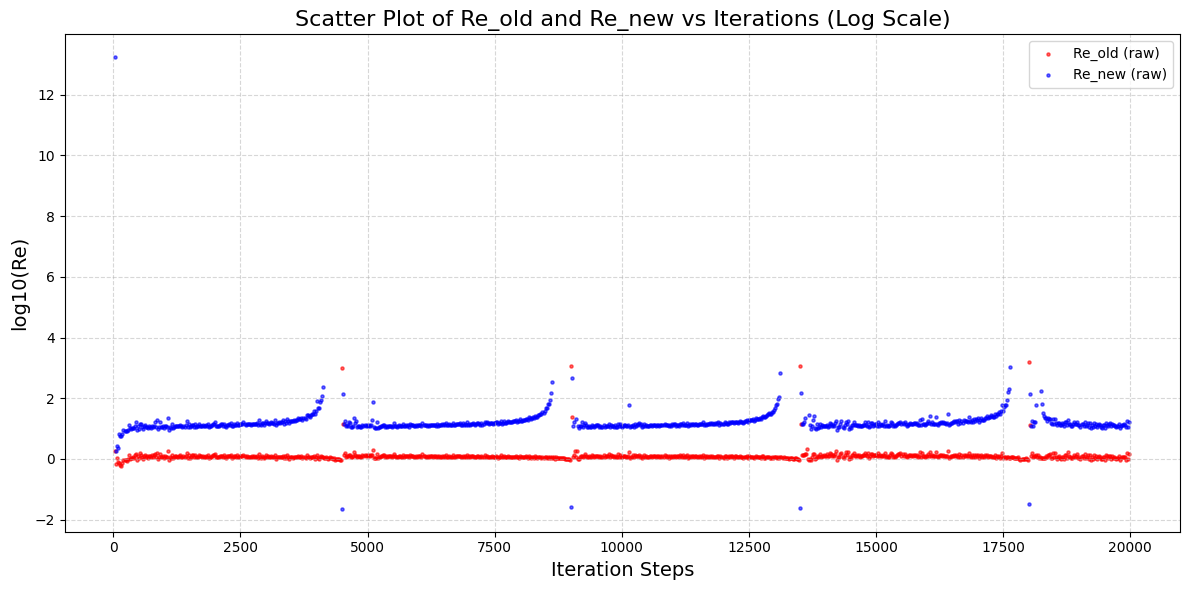

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the data
file_path = '/content/re_GPT2-large_CodeAlpaca/experiment_results.npz'
data = np.load(file_path, allow_pickle=True)

# 2. Extract arrays
steps = data['steps']            # all recorded steps (length N)
re_old = data['Re_old_raw']      # only for steps when param_queue >= 3 (length M)
re_new = data['Re_new_raw']      # same length M

print(f"Total recorded steps: {len(steps)}")
print(f"Re_old/Re_new points: {len(re_old)}")

# 3. Align steps with re_old/re_new
# The first (len(steps) - len(re_old)) entries in steps have no corresponding re_old/re_new.
offset = len(steps) - len(re_old)
steps_aligned = steps[offset:]   # take the last M steps

print(f"Aligned steps length: {len(steps_aligned)}")

# 4. Apply log10 (add small epsilon to avoid log(0) or negative values)
EPS = 1e-12
log_re_old = np.log10(re_old + EPS)
log_re_new = np.log10(re_new + EPS)

# 5. Scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(steps_aligned, log_re_old, s=5, alpha=0.6, color='red', label='Re_old (raw)')
plt.scatter(steps_aligned, log_re_new, s=5, alpha=0.6, color='blue', label='Re_new (raw)')
plt.xlabel('Iteration Steps', fontsize=14)
plt.ylabel('log10(Re)', fontsize=14)
plt.title('Scatter Plot of Re_old and Re_new vs Iterations (Log Scale)', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Total recorded Re steps: 1000
Re_old points: 998
Validation points: 39


/tmp/ipykernel_1986/432790780.py:26: RuntimeWarning: invalid value encountered in log10
  log_re_new = np.log10(re_new + EPS)


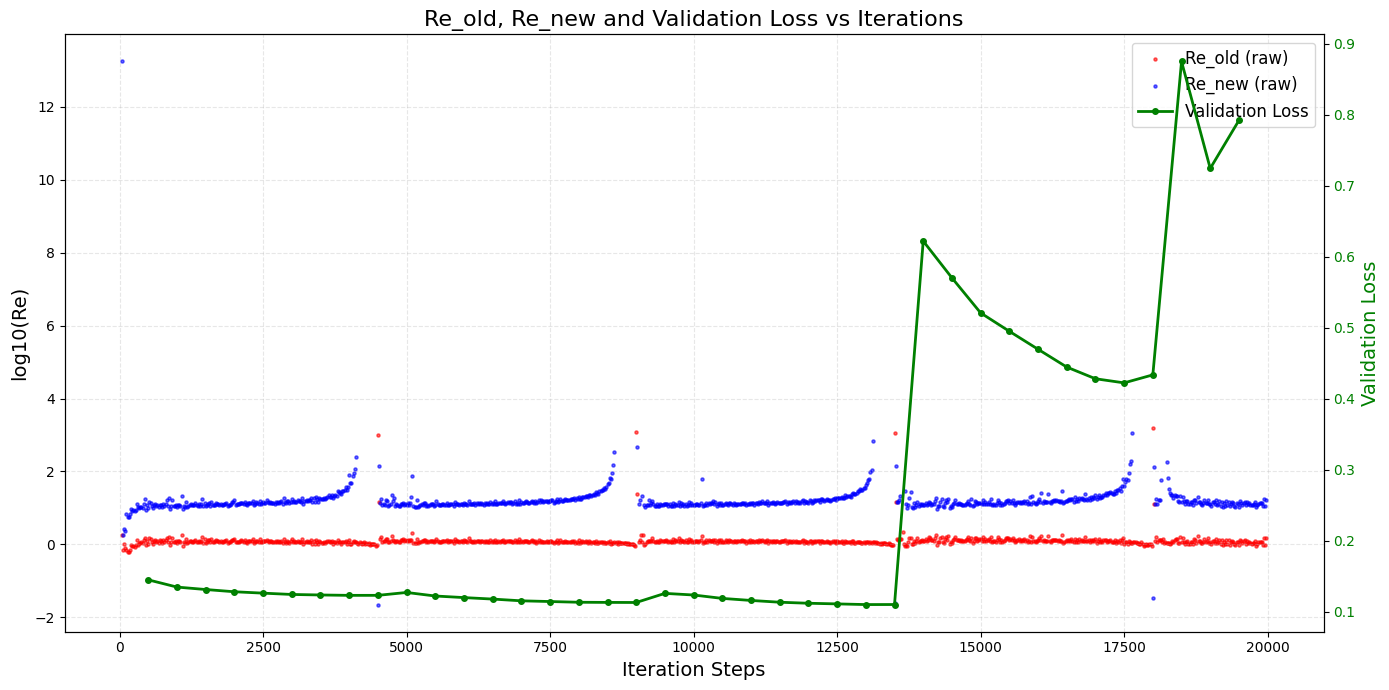

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the data
file_path = '/content/re_GPT2-large_CodeAlpaca/experiment_results.npz'
data = np.load(file_path, allow_pickle=True)

# 2. Extract all arrays
steps = data['steps']            # recorded steps for Re (length N)
re_old = data['Re_old_raw']      # length M (M = N - 2)
re_new = data['Re_new_raw']      # length M
val_loss = data['val_loss']      # validation loss values (recorded every VAL_INTERVAL)
val_steps = data['val_steps']    # corresponding steps for val_loss

print(f"Total recorded Re steps: {len(steps)}")
print(f"Re_old points: {len(re_old)}")
print(f"Validation points: {len(val_loss)}")

# 3. Align Re data: skip the first (N - M) steps where Re is not available
offset = len(steps) - len(re_old)
steps_aligned = steps[offset:]   # now length M

# 4. Apply log10 to Re (add small epsilon to avoid log(0) or negative)
EPS = 1e-12
log_re_old = np.log10(re_old + EPS)
log_re_new = np.log10(re_new + EPS)

# 5. Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- Left y-axis: log10(Re) ---
ax1.scatter(steps_aligned, log_re_old, s=5, alpha=0.6, color='red', label='Re_old (raw)')
ax1.scatter(steps_aligned, log_re_new, s=5, alpha=0.6, color='blue', label='Re_new (raw)')
ax1.set_xlabel('Iteration Steps', fontsize=14)
ax1.set_ylabel('log10(Re)', fontsize=14, color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, linestyle='--', alpha=0.3)

# --- Right y-axis: Validation Loss ---
ax2 = ax1.twinx()
ax2.plot(val_steps, val_loss, color='green', linewidth=2, marker='o', markersize=4, label='Validation Loss')
ax2.set_ylabel('Validation Loss', fontsize=14, color='green')
ax2.tick_params(axis='y', labelcolor='green')

# 6. Titles and legends (combine handles from both axes)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=12)

plt.title('Re_old, Re_new and Validation Loss vs Iterations', fontsize=16)
plt.tight_layout()
plt.show()